<font size = "3">

**(Q1)** Below is the `build_parse_tree` function we saw in class, along with some  example calls to the function.

In [1]:
from assign4_utils import Stack, BinaryTree

def build_parse_tree(fp_expr):
    fp_list = fp_expr.split()
    p_stack = Stack()
    expr_tree = BinaryTree("")
    # p_stack.push(expr_tree)
    p_stack.push(None) # I think this is more clear
    current_tree = expr_tree

    for i in fp_list:
        if i == "(":
            current_tree.insert_left("")
            p_stack.push(current_tree)
            current_tree = current_tree.left_child
        elif i in ["+", "-", "*", "/"]:
            current_tree.key = i
            current_tree.insert_right("")
            p_stack.push(current_tree)
            current_tree = current_tree.right_child
        elif i.isdigit():
              current_tree.key = int(i)
              parent = p_stack.pop()
              current_tree = parent
        elif i == ")":
              current_tree = p_stack.pop()
        else:
              raise ValueError(f"Unknown operator '{i}'")

    return expr_tree

pt = build_parse_tree("( 10 + 3 )")
pt.postorder()

10
3
+


In [2]:
expr = "( ( ( 4 * 3 ) + ( 5 * 2 ) ) / 2 )"
pt = build_parse_tree(expr)
pt.postorder()

4
3
*
5
2
*
+
2
/


<font size = "3">

Modify the function to define `build_parse_tree_v2` which does not require the outermost parentheses in an expression.

In [ ]:
def build_parse_tree_v2(fp_expr):
    return build_parse_tree(f"( {fp_expr} )") # just add parentheses 



In [4]:
# This should return a tree with 
# the following values in a postorder traversal: 10 3 +
pt = build_parse_tree_v2("10 + 3")
pt.postorder()

10
3
+


In [5]:
# This should return a tree with 
# the following values in a postorder traversal: 4 3 * 5 2 * + 2 /
expr = "( ( 4 * 3 ) + ( 5 * 2 ) ) / 2"
pt = build_parse_tree_v2(expr)
pt.postorder()

4
3
*
5
2
*
+
2
/


<font size = "3">

**(Q2)** We can "invert" the procedure that converts a string into a parse tree using the `print_exp` function:

In [6]:
def print_exp(tree):
    result = ""
    if tree:
        result = "(" + print_exp(tree.left_child)
        result = result + str(tree.key)
        result = result + print_exp(tree.right_child) + ")"
    return result

pt = build_parse_tree("( ( 10 + 5 ) * 3 )")

pt_str = print_exp(pt)

print(pt_str)

(((10)+(5))*(3))


<font size = "3">

Modify the function so that it does not include the extra parentheses around each individual number.

I.e. the modified function would return the string `((10 + 5)*3)`

In [ ]:
def print_exp_modified(tree):
    result = ""
    if tree.left_child is None and tree.right_child is None:
        return str(tree.key)  # return only key, no parentheses
    result = "(" + print_exp_modified(tree.left_child) + str(tree.key) + print_exp_modified(tree.right_child) + ")" 
    return result

pt = build_parse_tree("( ( 10 + 5 ) * 3 )")
pt_str = print_exp_modified(pt)
print(pt_str)

((10+5)*3)


<font size = "3">

**(Q3)** Create a binary heap class with a limited heap size. In other words, the heap only keeps track of the $m$
most important items. If the heap grows in size to more than $m$ items the least important item is dropped (while maintaining the binary heap structure).

Continue to use the *min heap* framework, where the least important item has the largest key value.

In [9]:
class BinaryHeap:
    def __init__(self):
        self._heap = []

    def _perc_up(self, i):
        while (i - 1) // 2 >= 0:
            p = (i - 1) // 2
            if self._heap[i] < self._heap[p]:
                self._heap[i],self._heap[p] = (
                    self._heap[p], self._heap[i]
                )
            else:
                break
            i = p

    def insert(self, item):
        self._heap.append(item)
        self._perc_up(len(self._heap) - 1)

    def _get_min_child(self, i):
        if 2 * i + 2 > len(self._heap) - 1: # no right child
            return 2 * i + 1
        if self._heap[2 * i + 1] < self._heap[2 * i + 2]:
            # tie -> take right_child
            return 2 * i + 1
        return 2 * i + 2
    
    def _perc_down(self, i):
        while 2 * i + 1 < len(self._heap):
            sm_child = self._get_min_child(i)
            if self._heap[i] > self._heap[sm_child]:
                self._heap[i], self._heap[sm_child] = (
                    self._heap[sm_child], self._heap[i]
                )
            else:
                break
            i = sm_child

    def delete(self):
        # swap, pop, percolate down
        self._heap[0], self._heap[-1] = self._heap[-1], self._heap[0]
        result = self._heap.pop()
        self._perc_down(0)
        return result

    def heapify(self, not_a_heap):
        # make a copy of the input list
        self._heap = not_a_heap[:]
        # left-most node in second-lowest level
        i = len(self._heap) // 2 - 1
        while i >= 0:
            self._perc_down(i)
            i = i - 1
    
    def is_empty(self):
        return not bool(self._heap)

    def __len__(self):
        return len(self._heap)

    def __str__(self):
        return str(self._heap)

In [ ]:
# your code here
class LimitedBinaryHeap(BinaryHeap):
    def __init__(self, m):
        super().__init__()
        self.m = m   # maximum number 

    def _find_max_index(self):        
        max_index = 0
        for i in range(1, len(self._heap)):
            if self._heap[i] > self._heap[max_index]: # find the index of the largest key
                max_index = i
        return max_index

    def _delete_max(self):
        max_index = self._find_max_index()
        # swap with max, pop, percolate down
        last = len(self._heap) - 1
        self._heap[max_index], self._heap[last] = (
            self._heap[last], self._heap[max_index]
        )
        self._heap.pop()
        if max_index < len(self._heap):
            self._perc_down(max_index)

    def insert(self, item):
        if len(self._heap) < self.m:
            super().insert(item)

        # if heap is too large, remove the least important item
        else:
            max_index = self._find_max_index()
            if item < self._heap[max_index]:
                self._delete_max()
                super().insert(item)

<font size = "3">

**(Q4)** Using the `heapify` function, write a sorting function that can sort a sorted list in $\mathcal{O}(n\log n)$ time.

Keep the following in mind as you design your algorithm:

- The `heapify` method is an $\mathcal{O}(n)$ operation.

- "Percolating" up or down is an $\mathcal{O}(\log n)$ operation.

- Swapping two items in a list is an $\mathcal{O}(1)$ operation.

- Popping from the end of a list is an $\mathcal{O}(1)$ operation.

- Popping from the beginning of a list is an $\mathcal{O}(n)$ operation.

You might find it convenient to write an independent `heapify` function instead of calling the method from a `BinaryHeap` object.

In [12]:
# your code here
def heapify(lst):
    n = len(lst)
    i = n // 2 - 1
    while i >= 0:
        _perc_down(lst, i, n)
        i -= 1

def _get_min_child(heap, i, size):
    left = 2 * i + 1
    right = 2 * i + 2

    if right >= size:
        return left
    if heap[left] < heap[right]:
        return left
    return right


def _perc_down(heap, i, size):
    while 2 * i + 1 < size:
        mc = _get_min_child(heap, i, size)
        if heap[i] > heap[mc]:
            heap[i], heap[mc] = heap[mc], heap[i]
            i = mc
        else:
            break

def heapsort(lst):
    heap = lst[:]
    heapify(heap)

    result = []
    size = len(heap)

    while size > 0:
        heap[0], heap[size - 1] = heap[size - 1], heap[0]
        result.append(heap.pop())
        size -= 1
        if size > 0:
            _perc_down(heap, 0, size)

    return result


print(heapsort([4, 2, 5, 1, 6, 3]))

[1, 2, 3, 4, 5, 6]


<font size = "3">

**(Q5)** Empirically verify that the function you wrote for Question 4 has $\mathcal{O}(n \log n)$ cost by testing it on lists of integers of different sizes.

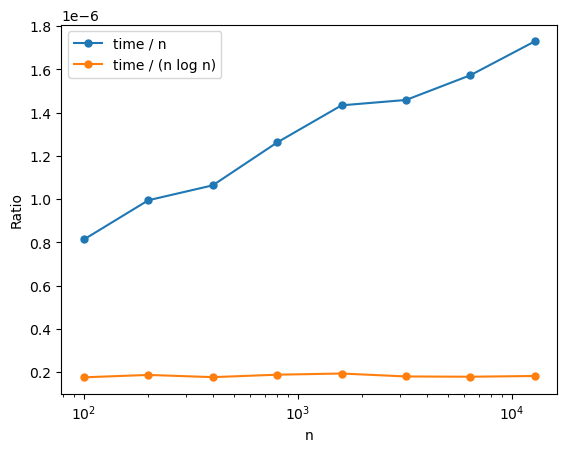

In [ ]:
# your code here
import numpy as np
import matplotlib.pyplot as plt
from timeit import default_timer
import random

n_values    = np.array([100, 200, 400, 800, 1600, 3200, 6400, 12800])
num_repeats = 10 
average_times = []

for n in n_values:
    total = 0
    for _ in range(num_repeats):
        lst = random.sample(range(10 * n), n)   
        start = default_timer()
        heapsort(lst)
        stop  = default_timer()
        total += stop - start
    average_times.append(total / num_repeats)

average_times = np.array(average_times)

# ratio plot
plt.semilogx(n_values, average_times / n_values, '.-', label='time / n', markersize=10)
plt.semilogx(n_values, average_times / (n_values * np.log(n_values)),
             '.-', label='time / (n log n)', markersize=10)
plt.xlabel('n')
plt.ylabel('Ratio')
plt.legend()
plt.show()